In [1]:
from astropy.table import Table
import pandas as pd

url = "https://exoplanetarchive.ipac.caltech.edu/data/ExoData/0113/0113357/data/UID_0113357_RVC_001.tbl"

table = Table.read(url, format='ascii')
df = table.to_pandas()

import os
print("Saving in:", os.getcwd())

df.to_csv("51_peg_self.csv", index=False)

print("Saved successfully!")

Saving in: C:\Users\rsrut\Documents\astro-learning
Saved successfully!


In [3]:
import pandas as pd
df = pd.read_csv("51_peg_self.csv")
print(df.columns.tolist())
print(df.head(10)) # astropy automatically ignores header columns

['JD', 'Radial_Velocity', 'Radial_Velocity_Uncertainty']
             JD  Radial_Velocity  Radial_Velocity_Uncertainty
0  2.450003e+06            -52.9                          4.1
1  2.450003e+06            -45.8                          4.8
2  2.450003e+06            -60.8                          4.6
3  2.450003e+06            -53.3                          5.0
4  2.450003e+06            -60.9                          5.5
5  2.450003e+06            -57.3                          7.0
6  2.450004e+06            -24.2                          5.0
7  2.450004e+06            -30.5                          4.6
8  2.450004e+06            -26.0                          4.9
9  2.450004e+06            -19.2                          4.2


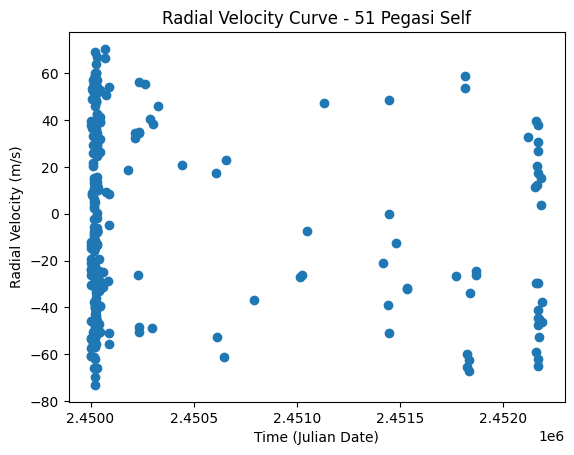

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df['JD'], df['Radial_Velocity'])

plt.xlabel("Time (Julian Date)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve - 51 Pegasi Self")

plt.savefig("51_peg_self_plot.png")

plt.show()

Best period found: 4.2310 days
Expected from thesis: 4.2308 days


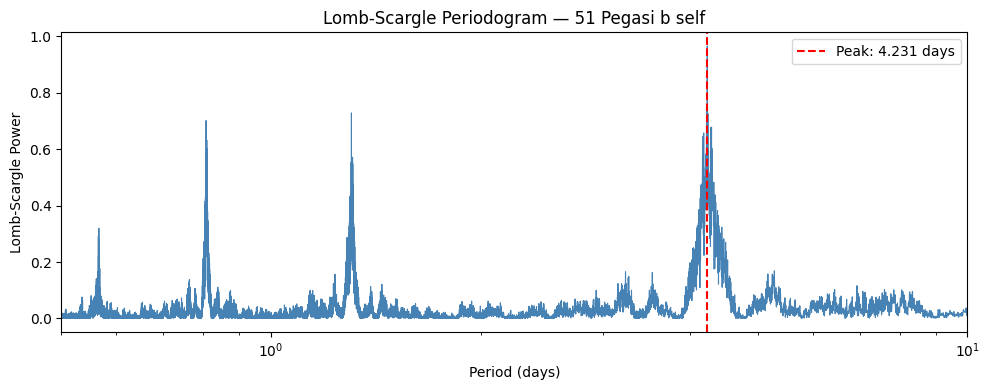

Done


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import pandas as pd

df = pd.read_csv("51_peg_self.csv")


# Load the data
t = df['JD'].values
rv = df['Radial_Velocity'].values
rv_err = df['Radial_Velocity_Uncertainty'].values

# Run Lomb-Scargle
frequency, power = LombScargle(t, rv, rv_err).autopower(minimum_frequency=0.1, 
                                                          maximum_frequency=2.0)

# Convert frequency to period in days
period = 1.0 / frequency

# Find the peak
best_frequency = frequency[np.argmax(power)]
best_period = 1.0 / best_frequency

print(f"Best period found: {best_period:.4f} days")
print(f"Expected from thesis: 4.2308 days")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(period, power, color='steelblue', linewidth=0.8)
plt.axvline(best_period, color='red', linestyle='--', label=f'Peak: {best_period:.3f} days')
plt.xlabel('Period (days)')
plt.ylabel('Lomb-Scargle Power')
plt.title('Lomb-Scargle Periodogram — 51 Pegasi b self')
plt.xscale('log')
plt.xlim(0.5, 10)
plt.legend()
plt.tight_layout()
plt.savefig('51peg_self_periodogram.png', dpi=150)
plt.show()
print("Done")

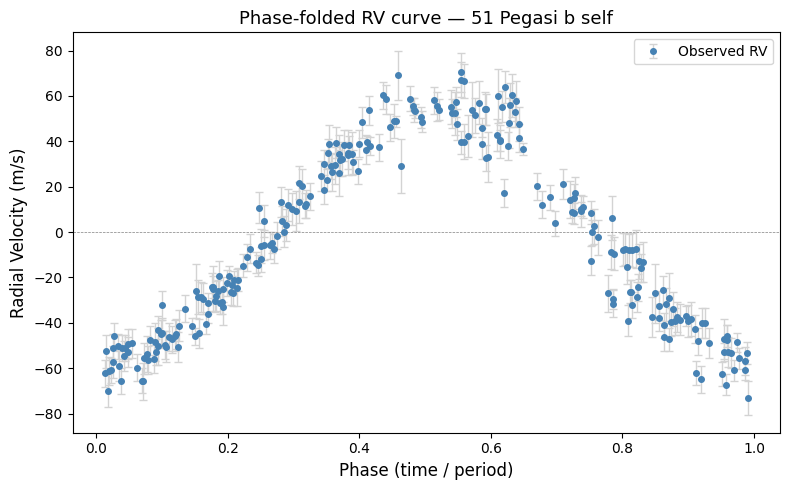

Phase fold done.


In [5]:
period = 4.2310

# Phase fold: this compresses all observations onto one single orbit
# The % operator gives the remainder — so any time value maps to 0 to period
# Dividing by period maps it to 0 to 1 (one full orbit = phase 0 to 1)
phase = (t % period) / period

# Plot the phase-folded curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(phase, rv, yerr=rv_err,
            fmt='o',           # circular markers
            color='steelblue',
            ecolor='lightgray',  # error bar color
            elinewidth=1,
            capsize=3,
            markersize=4,
            label='Observed RV')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')  # zero line
ax.set_xlabel('Phase (time / period)', fontsize=12)
ax.set_ylabel('Radial Velocity (m/s)', fontsize=12)
ax.set_title('Phase-folded RV curve — 51 Pegasi b self', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("51peg_self_phase_folded.png", dpi=150)
plt.show()
print("Phase fold done.")